In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [58]:
level1 = sensorClasses.Sensor(dataset, id=1041)
pump_flow = sensorClasses.Sensor(dataset, id=1049)
pump_diff = sensorClasses.Sensor(dataset, id=1048)
cryo_press = sensorClasses.Sensor(dataset, id=1011)

In [48]:
tgrad = systemClasses.System(dataset, "TGRAD")

Initializing TGRAD Sensors: 100%|██████████| 48/48 [00:16<00:00,  2.97sensor/s]


In [49]:
tgrad.calibrate("SECOND_POFF_OCTOBER")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:15<00:00,  3.16sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:01<00:00, 34.26sensor/s]


# Lar Flow

The goal of this script is to analyze the effect of the value of the LAr flow has on the temperature profiles and on the bulk temperature

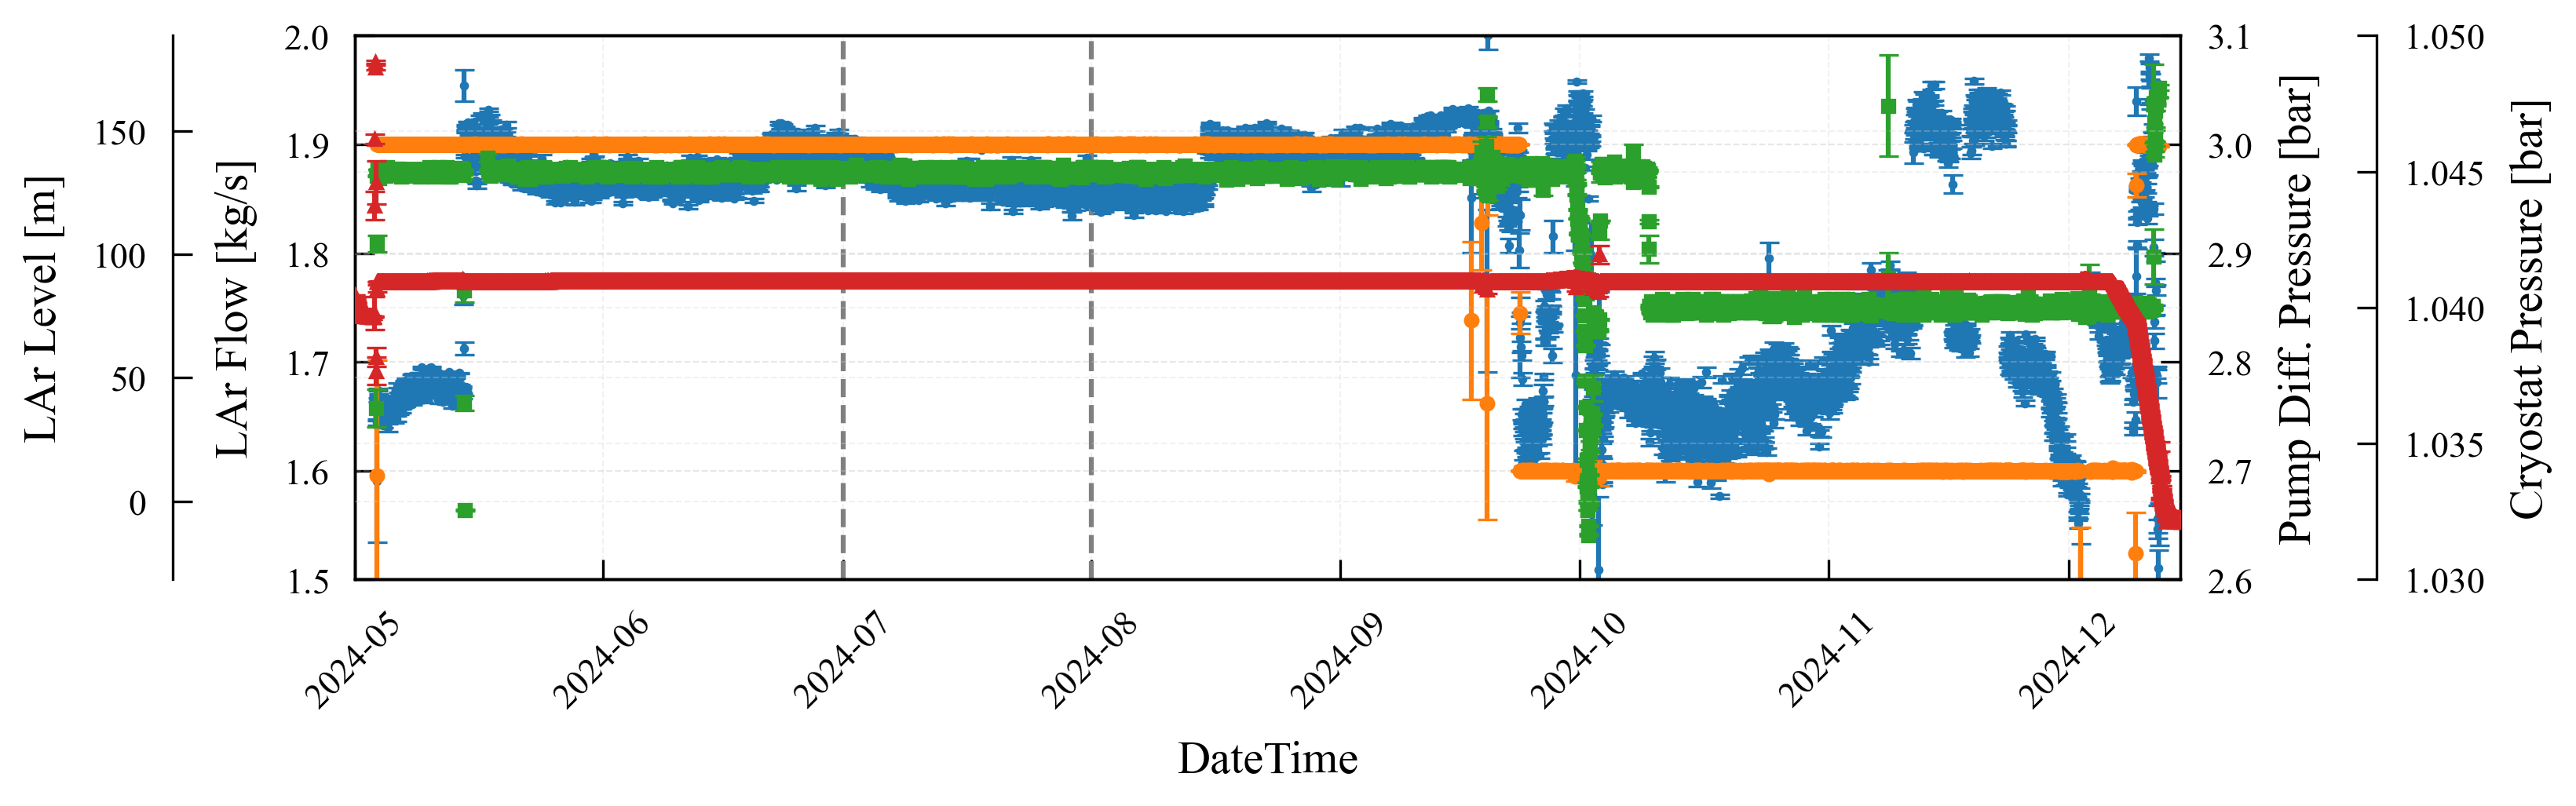

In [60]:
fig, axes = plt.subplots(1,1)
fig.set_size_inches(10,3)
axes.errorbar(pump_flow.data.resample("60min").mean().index.values, pump_flow.data.resample("60min").mean().values, yerr=pump_flow.data.resample("60min").sem().values, marker=".", linestyle="None")
axes.set_xlabel("DateTime")
axes.set_ylabel("LAr Flow [kg/s]")
axes.set_ylim(1.5, 2)
axes.set_xlim(datetime.datetime(2024, 5, 1), datetime.datetime(2024, 12, 15))
axes2 = axes.twinx()
axes2.errorbar(pump_diff.data.resample("60min").mean().index.values, pump_diff.data.resample("60min").mean().values, yerr=pump_diff.data.resample("60min").sem().values, marker="o", linestyle="None", color="tab:orange")
axes2.set_ylabel("Pump Diff. Pressure [bar]")
axes2.set_ylim(2.6, 3.1)
axes3 = axes.twinx()
axes3.spines["right"].set_position(("outward", 60))
axes3.errorbar(cryo_press.data.resample("60min").mean().index.values, cryo_press.data.resample("60min").mean().values, yerr=cryo_press.data.resample("60min").sem().values, marker="s", linestyle="None", color="tab:green")
axes3.set_ylim(1.03, 1.05)
axes3.set_ylabel("Cryostat Pressure [bar]")
axes4 = axes.twinx()
axes4.spines["left"].set_position(("axes", -0.1))  # adjust offset as needed
axes4.yaxis.set_label_position("left")
axes4.yaxis.set_ticks_position("left")

axes4.spines["right"].set_visible(False)
axes4.errorbar(level1.data.resample("60min").mean().index.values, level1.data.resample("60min").mean().values, yerr=level1.data.resample("60min").sem().values, marker="^", linestyle="None", color="tab:red")
axes4.set_ylabel("LAr Level [m]")
axes.tick_params(axis="x", rotation=45)
t1 = datetime.datetime(2024, 7, 1)
t2 = datetime.datetime(2024, 8, 1)
axes.axvline(t1, color="gray", linestyle="--")
axes.axvline(t2, color="gray", linestyle="--")

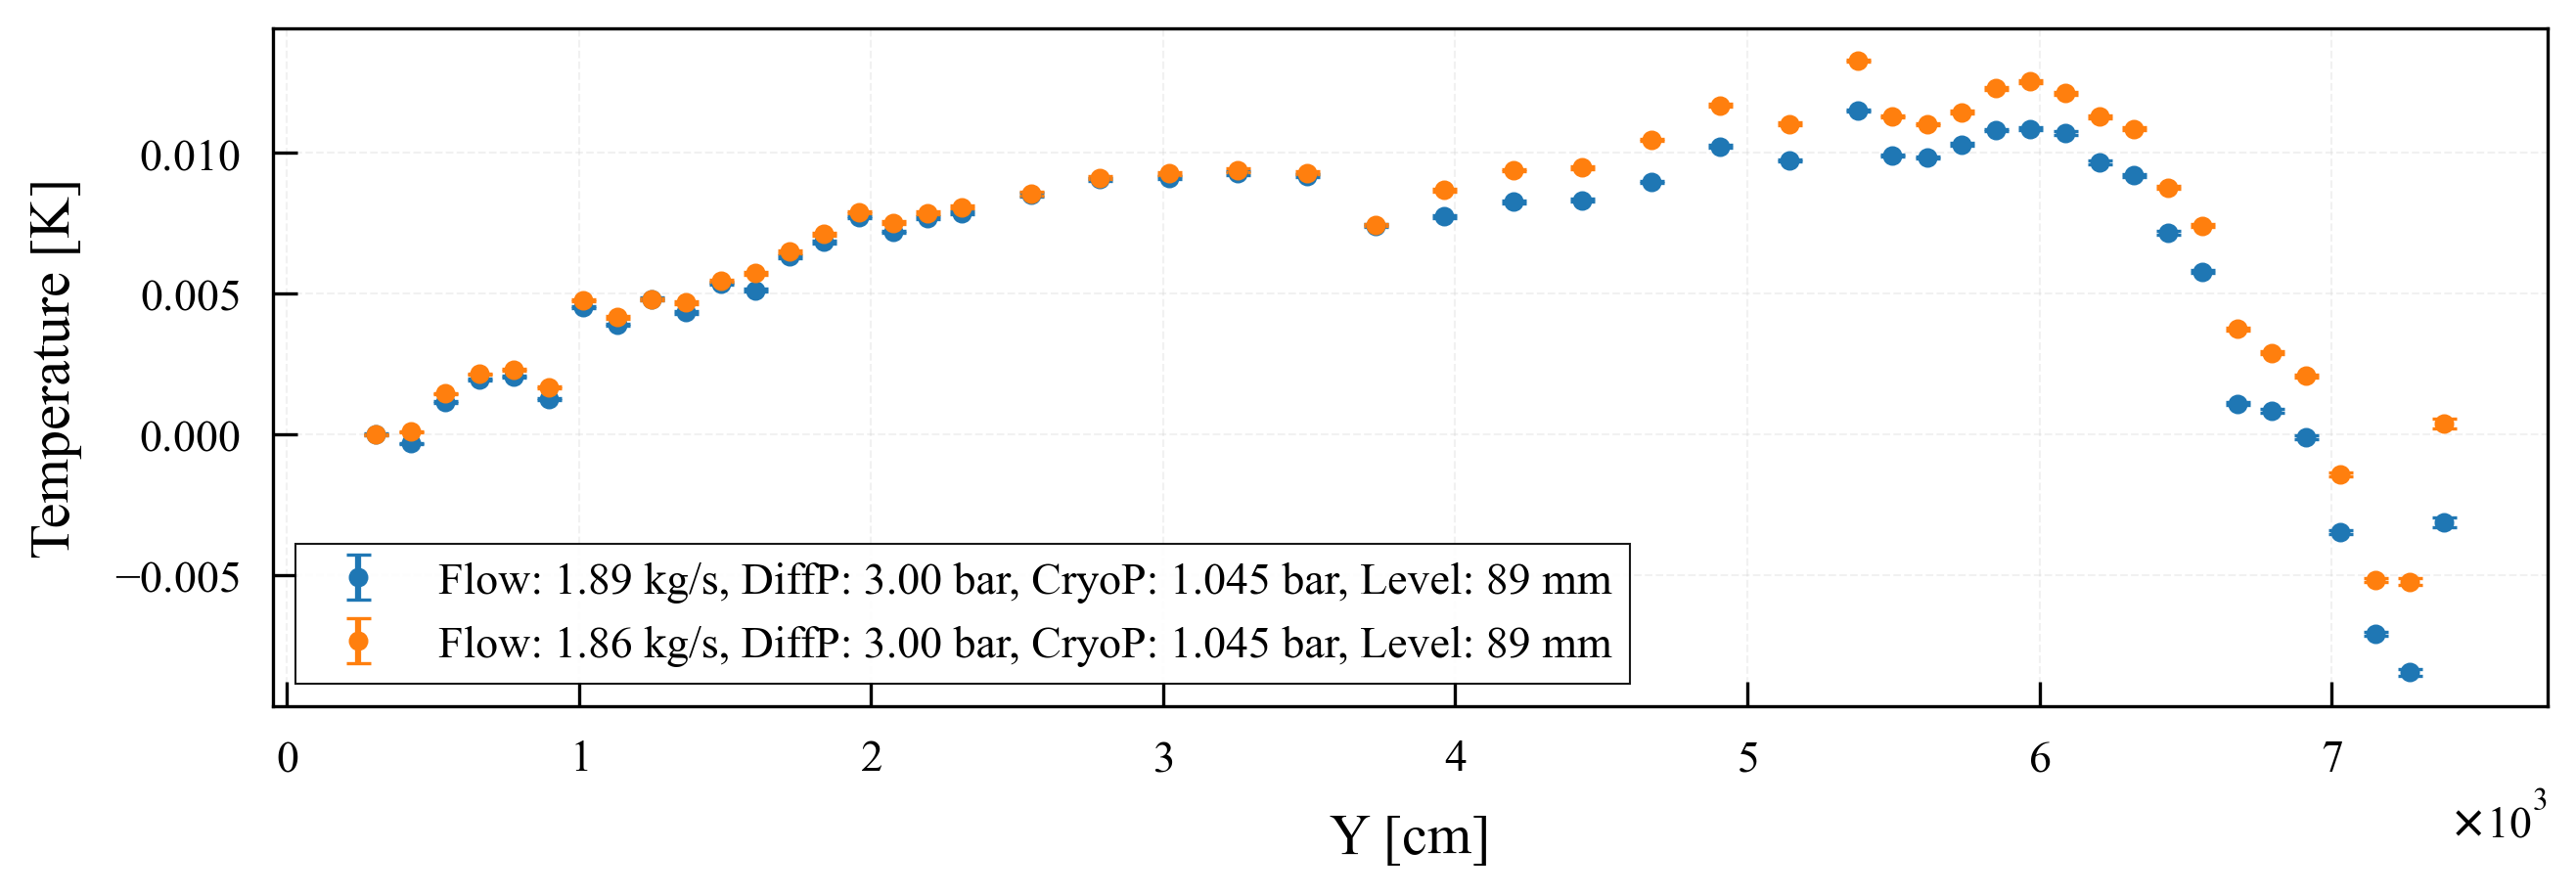

In [64]:
fig, axes = plt.subplots(1,1)
fig.set_size_inches(10,3)
tgrad.makeProfiles(tini=t1, tend=t1+datetime.timedelta(days=1))
lar_flow1 = pump_flow.data.loc[t1:t1+datetime.timedelta(days=1)].mean()
pump_diff1 = pump_diff.data.loc[t1:t1+datetime.timedelta(days=1)].mean()
cryo_press1 = cryo_press.data.loc[t1:t1+datetime.timedelta(days=1)].mean()
lar_level1 = level1.data.loc[t1:t1+datetime.timedelta(days=1)].mean()
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0], yerr=tgrad.profiles["err"].values, marker="o", linestyle="None", label=f"Flow: {lar_flow1:.2f} kg/s, DiffP: {pump_diff1:.2f} bar, CryoP: {cryo_press1:.3f} bar, Level: {lar_level1:.0f} mm")
tgrad.makeProfiles(tini=t2, tend=t2+datetime.timedelta(days=1))
lar_flow2 = pump_flow.data.loc[t2:t2+datetime.timedelta(days=1)].mean()
pump_diff2 = pump_diff.data.loc[t2:t2+datetime.timedelta(days=1)].mean()
cryo_press2 = cryo_press.data.loc[t2:t2+datetime.timedelta(days=1)].mean()
lar_level2 = level1.data.loc[t2:t2+datetime.timedelta(days=1)].mean()
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0], yerr=tgrad.profiles["err"].values, marker="o", linestyle="None", label=f"Flow: {lar_flow2:.2f} kg/s, DiffP: {pump_diff2:.2f} bar, CryoP: {cryo_press2:.3f} bar, Level: {lar_level2:.0f} mm")
axes.set_xlabel("Y [cm]")
axes.set_ylabel("Temperature [K]")
axes.legend()